Introduction:

Diabetes is a chronic disease that affects millions of people worldwide. Early prediction and diagnosis are crucial for effective management and prevention of complications. In this project, we aim to build machine learning models to predict whether a patient is diabetic based on various medical and demographic features.



Diabetes Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Preprocessing:

Loading and Exploring Data

We loaded the dataset using pandas and performed initial exploration to understand its structure.

In [3]:
db = pd.read_csv('diabetes_data_upload (3) (1).csv')
db.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [4]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [5]:
db.isnull().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

Encoding Categorical Variables:

Most features are categorical (Yes/No or Male/Female).

We encoded these variables into numerical values for modeling.



In [6]:
#encoding categorical variables
db_encoded = db.copy()
db_encoded['Gender'] = db_encoded['Gender'].map({'Male': 1, 'Female': 0})
for col in db_encoded.columns:
    if db_encoded[col].dtype == 'object' and col not in ['Gender', 'class']:
        db_encoded[col] = db_encoded[col].map({'Yes': 1, 'No': 0})
db_encoded['class'] = db_encoded['class'].map({'Positive': 1, 'Negative': 0})
db_encoded.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


Exploratory Data Analysis

Class Distribition

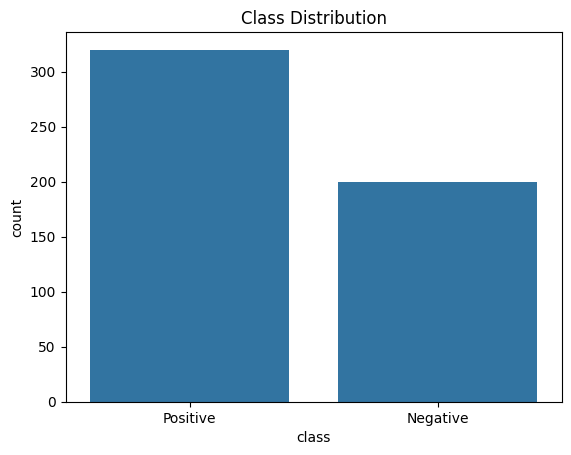

In [7]:
sns.countplot(x='class', data=db)
plt.title('Class Distribution')
plt.show()

Observation: The dataset is slightly imbalanced, with 320 Positive and 220 Negative cases.

Age Distribition by Class

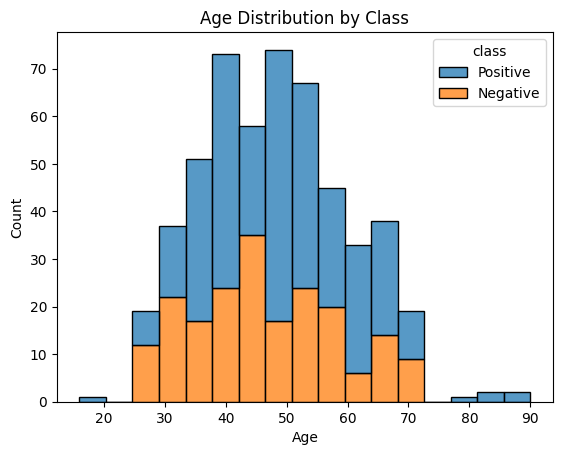

In [8]:
sns.histplot(data=db, x='Age', hue='class', multiple='stack')
plt.title('Age Distribution by Class')
plt.show()

Gender Distribution by Class

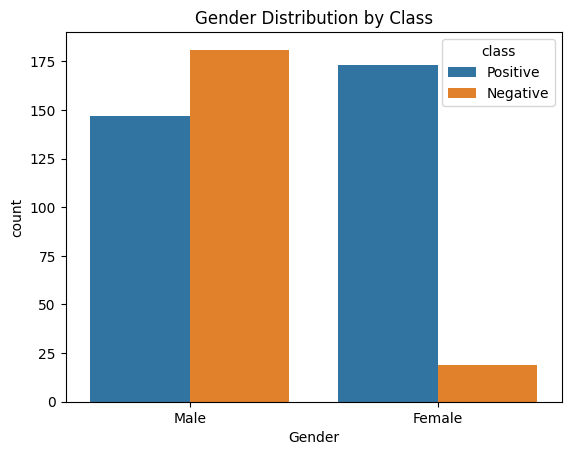

In [9]:
#Gender distribution by class
sns.countplot(x='Gender', hue='class', data=db)
plt.title('Gender Distribution by Class')
plt.show()

Correlation Analysis

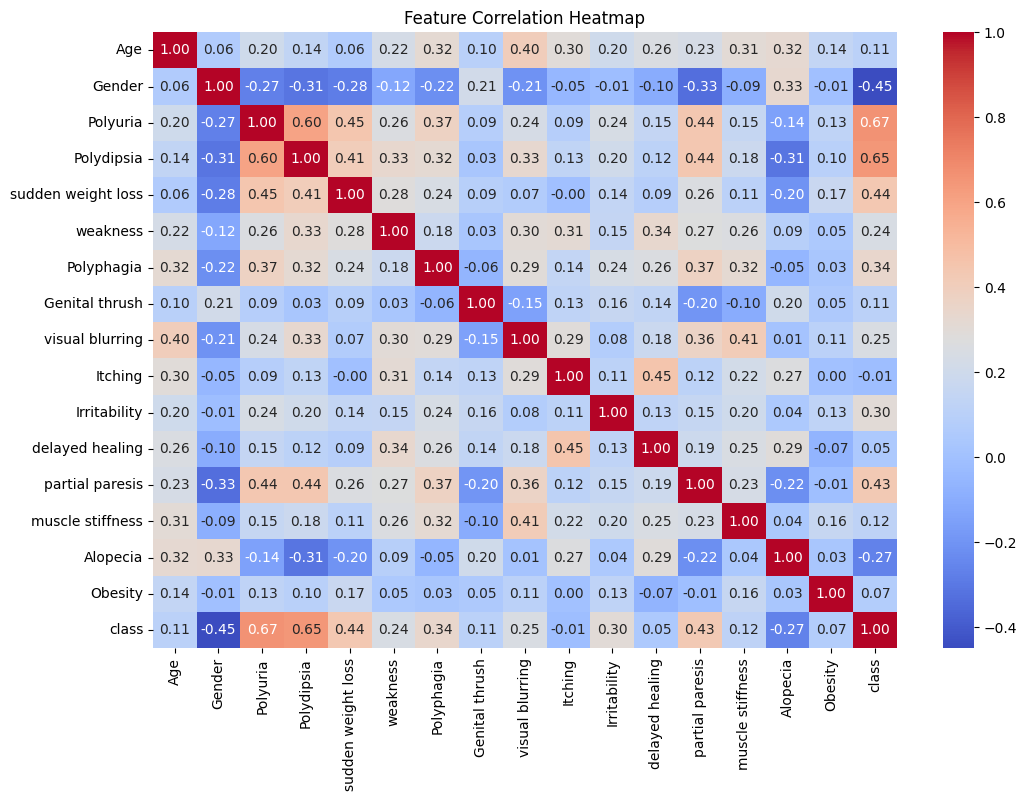

In [10]:
#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(db_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

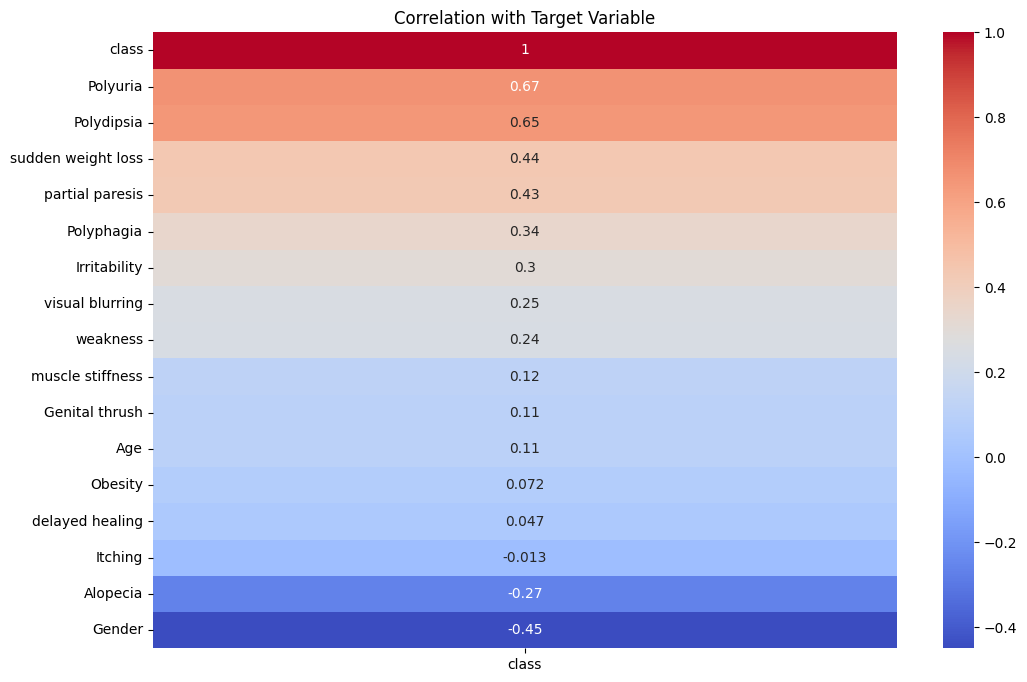

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(db_encoded.corr()[['class']].sort_values(by='class', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Target Variable')
plt.show()

Modelling

Data Splitting:

To ensure the class distribution is preserved in both training and test sets, we used stratified sampling.

In [12]:
from sklearn.model_selection import train_test_split

# X: features, y: target
X = db_encoded.drop('class', axis=1)
y = db_encoded['class']

# Stratified split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Check class distribution in splits
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Train class distribution:
 class
1    256
0    160
Name: count, dtype: int64
Test class distribution:
 class
1    64
0    40
Name: count, dtype: int64


Model Building:

We built and evaluated two machine learning models: Support Vector Machine (SVM) and K-Nearest Neighbors (KNN).

Support Vector Machine(SVM)

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear',C=1,random_state=42)
# Fit the model on the training data
svm_classifier.fit(X_train, y_train)
# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)
# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
#accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")



Confusion Matrix:
 [[39  1]
 [ 6 58]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92        40
           1       0.98      0.91      0.94        64

    accuracy                           0.93       104
   macro avg       0.92      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104

Accuracy: 0.93


K-Nearest Neighbour(KNN)

In [26]:
# Initialize the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5, p=1, weights='distance')
# Fit the model on the training data
knn_classifier.fit(X_train, y_train)
# Make predictions on the test set
y_pred_knn = knn_classifier.predict(X_test)
# Evaluate the KNN model
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
# KNN accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.2f}")


KNN Confusion Matrix:
 [[40  0]
 [ 3 61]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        40
           1       1.00      0.95      0.98        64

    accuracy                           0.97       104
   macro avg       0.97      0.98      0.97       104
weighted avg       0.97      0.97      0.97       104

KNN Accuracy: 0.97
